==========================================================================
# 📁 **ATIVIDADE FIAP - Cap 1 - Visão Computacional na Clínica**
==========================================================================

**Autor.....:** Diego Nunes Veiga

**RM........:** 560658

**Turma...:** Graduação - 1TIAOR

**Data......:** 25/09/2025

==========================================================================


---
## **↪ Bibliotecas**
---



In [ ]:
!pip install -q kagglehub[pandas-datasets]

In [ ]:
import os
import shutil
from google.colab import files

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Model, layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

---
## **↪ Subalgoritmos**
---



In [ ]:
# Cópia dos arquivos de imagem
# ---------------------------------------------------------------------------

def CopyImagem(fonte, diretorio) -> None:
  if not os.path.exists(diretorio):
      shutil.copytree(fonte, diretorio)
      print("Pasta bbox_img copiada para:", diretorio)
  else:
      print("Pasta bbox_img já existe em:", diretorio)

In [ ]:
# Cópia dos arquivo CSV
# ---------------------------------------------------------------------------

def CopyCSV(fonte, diretorio) -> None:
  if not os.path.exists(diretorio):
      shutil.copyfile(fonte, diretorio)
      print("Arquivo tensorflow.csv copiado para:", diretorio)
  else:
      print("CSV já existe em:", diretorio)

In [ ]:
# Treinamento do modelo CNN
# ---------------------------------------------------------------------------

def TreinoValidacao(df, coluna, rdm_state):

    # Primeiro split: 70% treino, 30% temporário
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df[coluna], random_state=rdm_state)

    # Segundo split: 30% restante -> 15% validação / 15% teste
    val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df[coluna], random_state=rdm_state)

    return train_df, val_df, test_df


In [ ]:
# Criação dos geradores de dados
# ---------------------------------------------------------------------------

def CriaGeradores(generator,dataframe,directory,x_col,y_col,target_size,color_mode,class_mode,batch_size,shuffle):
    return generator.flow_from_dataframe(dataframe=dataframe,
                                         directory=directory,
                                         x_col=x_col,
                                         y_col=y_col,
                                         target_size=target_size,
                                         color_mode=color_mode,
                                         class_mode=class_mode,
                                         batch_size=batch_size,
                                         shuffle=shuffle)

In [ ]:
# Apresentação dos Batch de imagens
# ---------------------------------------------------------------------------

def VisualizaBatchImagens(images, labels, class_indices, n_imagens):

    n_imagens = min(n_imagens, len(images))
    inv_map = {v: k for k, v in class_indices.items()}

    plt.figure(figsize=(10, 8))
    for i in range(n_imagens):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        if labels.ndim > 1 and labels.shape[1] > 1:
            class_idx = np.argmax(labels[i])
        else:
            class_idx = int(labels[i])
        plt.title(inv_map[class_idx])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
# Criação do modelo CNN do zero
# ---------------------------------------------------------------------------

def CriarCNN_Simples(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation="relu", input_shape=input_shape),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

    return model

In [ ]:
# Criação do modelo Transfer Learning
# ---------------------------------------------------------------------------

def CriarModelo_TransferLearning(input_shape, num_classes):
    base = VGG16(weights="imagenet",include_top=False,input_shape=input_shape)

    # Congelar a base
    base.trainable = False

    # Construir cabeça personalizada
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

    return model

In [ ]:
# Criação do modelos (CNN, Transfer Learning)
# ---------------------------------------------------------------------------

def TreinarModelo(model, train_gen, val_gen, epochs):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs
    )
    return history

In [ ]:
# Avaliação dos modelos
# ---------------------------------------------------------------------------

def AvaliarModelo(model, test_gen):
    # Previsões
    test_gen.reset()
    preds = model.predict(test_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=test_gen.class_indices.keys(),
                yticklabels=test_gen.class_indices.keys())
    plt.title("Matriz de Confusão")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

    print("\nRelatório de Classificação:\n")
    print(classification_report(
        y_true, y_pred,
        target_names=list(test_gen.class_indices.keys())
    ))


In [ ]:
# Simuçlação de Classificação de Imagem
# ---------------------------------------------------------------------------
def ClassificarImagem(model, class_indices, target_size=(224,224)):
    uploaded = files.upload()
    inv_map = {v:k for k,v in class_indices.items()}

    for filename in uploaded.keys():
        img_path = filename
        img = image.load_img(img_path, target_size=target_size)
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_array)
        class_id = np.argmax(pred)
        prob = np.max(pred)

        print(f"\nImagem: {filename}")
        plt.imshow(img)
        plt.axis("off")
        plt.show()

        print(f"Classe prevista: {inv_map[class_id]}")
        print(f"Probabilidade: {prob:.4f}")


---
# **PROGRAMA PRINCIPAL**
---

### **PARTE 1**

### **↪ Extração dos dados**

In [ ]:
# Baixar o dataset NIH Chest X-rays Bbox version
# ---------------------------------------------------------------------------
root_path = kagglehub.dataset_download("huthayfahodeb/nih-chest-x-rays-bbox-version")
print("Dataset baixado em:", root_path)


# Deixar o projeto organizado em uma pasta própria no Colab
# ---------------------------------------------------------------------------
BASE_DATASET_DIR = "/content/nih_bbox_dataset"
os.makedirs(BASE_DATASET_DIR, exist_ok=True)

Using Colab cache for faster access to the 'nih-chest-x-rays-bbox-version' dataset.
Dataset baixado em: /kaggle/input/nih-chest-x-rays-bbox-version


###  **↪ Leitura dos dados**

In [ ]:
# Caminhos dos arquivos que serão utilizados
# ---------------------------------------------------------------------------

# Imagens de Raio X
SRC_IMAGES_DIR = os.path.join(root_path, "bbox_img")
DEST_IMAGES_DIR = os.path.join(BASE_DATASET_DIR, "bbox_img")

# Dados em CSV
SRC_CSV_PATH   = os.path.join(root_path, "tensorflow.csv")
DEST_CSV_PATH   = os.path.join(BASE_DATASET_DIR, "tensorflow.csv")

# Retorno dos locais
print("OS DADOS ESTÃO NAS SEGUINTES ORIGENS:")
print("Imagens:", SRC_IMAGES_DIR)
print("CSV:", SRC_CSV_PATH)


OS DADOS ESTÃO NAS SEGUINTES ORIGENS:
Imagens: /kaggle/input/nih-chest-x-rays-bbox-version/bbox_img
CSV: /kaggle/input/nih-chest-x-rays-bbox-version/tensorflow.csv


In [ ]:
# Cópia dos arquivos de imagens e CSV para iniciar o processamento dos dados
# ---------------------------------------------------------------------------

CopyImagem(SRC_IMAGES_DIR, DEST_IMAGES_DIR)
CopyCSV(SRC_CSV_PATH, DEST_CSV_PATH)

Pasta bbox_img já existe em: /content/nih_bbox_dataset/bbox_img
CSV já existe em: /content/nih_bbox_dataset/tensorflow.csv


In [ ]:
# Apresentação dos dados CSV
df = pd.read_csv(DEST_CSV_PATH)
print("Formato do CSV:", df.shape)
print("Colunas:", df.columns.tolist())
df.head()

Formato do CSV: (984, 8)
Colunas: ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']


,filename,width,height,class,xmin,ymin,xmax,ymax
0,00000032_037.png,1024,1024,Infiltrate,339.166138,119.195767,511.458201,470.281481
1,00000072_000.png,1024,1024,Atelectasis,356.503704,567.805291,484.368254,650.158730
2,00000147_001.png,1024,1024,Atelectasis,617.650794,599.229630,718.425397,779.106878
3,00000149_006.png,1024,1024,Atelectasis,603.661017,460.239556,853.152542,550.273454
4,00000150_002.png,1024,1024,Pneumonia,601.396825,595.978836,817.032804,776.939683


### **↪ Processamento dos dados**

In [ ]:
# Renomeando as counas do Dataframe
# ---------------------------------------------------------------------------

df = df.rename(columns={"filename": "Image Index", "class": "Label"})

df_unique = df.drop_duplicates(subset=["Image Index"]).copy()

print(df_unique["Label"].value_counts())
df_unique.head()


Label
Atelectasis     170
Cardiomegaly    146
Effusion        138
Pneumonia        98
Infiltrate       95
Pneumothorax     86
Nodule           79
Mass             68
Name: count, dtype: int64


,Image Index,width,height,Label,xmin,ymin,xmax,ymax
0,00000032_037.png,1024,1024,Infiltrate,339.166138,119.195767,511.458201,470.281481
1,00000072_000.png,1024,1024,Atelectasis,356.503704,567.805291,484.368254,650.158730
2,00000147_001.png,1024,1024,Atelectasis,617.650794,599.229630,718.425397,779.106878
3,00000149_006.png,1024,1024,Atelectasis,603.661017,460.239556,853.152542,550.273454
4,00000150_002.png,1024,1024,Pneumonia,601.396825,595.978836,817.032804,776.939683


### **↪ Treinamento do modelo**

In [ ]:
# Treinamento do modelo: 70% treino / 15% validação / 15% teste
# ---------------------------------------------------------------------------
train_df, val_df, test_df = TreinoValidacao(df_unique,"Label",42)

# Apresentação dos resutaltados obtidos
print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)

Treino: (616, 8)
Validação: (132, 8)
Teste: (132, 8)


In [ ]:
# Geradores do processamento de dados
# ---------------------------------------------------------------------------

# Geração dos dados de treino
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Geração dos dados de teste
test_val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
# Parametros das imagens
# ---------------------------------------------------------------------------

IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 32
size_image = (IMG_HEIGHT, IMG_WIDTH)

In [ ]:
# Gerando dados do treinamento, validação e teste
# ---------------------------------------------------------------------------

# Gerador de treinamento
train_generator = CriaGeradores(train_datagen,train_df,DEST_IMAGES_DIR,"Image Index","Label",size_image,"rgb","categorical",BATCH_SIZE,True)

# Gerador de validação
val_generator = CriaGeradores(test_val_datagen,val_df,DEST_IMAGES_DIR,"Image Index","Label",size_image,"rgb","categorical",BATCH_SIZE,False)

# Gerador de teste
test_generator = CriaGeradores(test_val_datagen,test_df,DEST_IMAGES_DIR,"Image Index","Label",size_image,"rgb","categorical",BATCH_SIZE,False)

# Apresentação das classes encontradas
print("Classes mapeadas:", train_generator.class_indices)

Found 616 validated image filenames belonging to 8 classes.
Found 132 validated image filenames belonging to 8 classes.
Found 132 validated image filenames belonging to 8 classes.
Classes mapeadas: {'Atelectasis': 0, 'Cardiomegaly': 1, 'Effusion': 2, 'Infiltrate': 3, 'Mass': 4, 'Nodule': 5, 'Pneumonia': 6, 'Pneumothorax': 7}


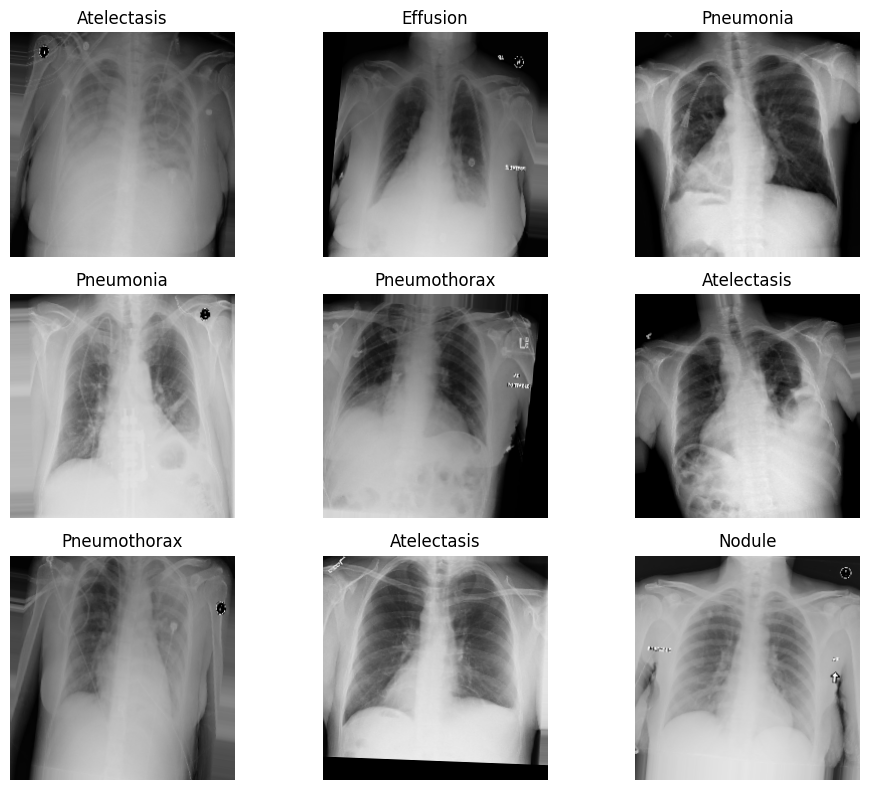

In [ ]:
# Apresentação das imagens com os labels correspondentes
# ---------------------------------------------------------------------------

images, labels = next(train_generator)
VisualizaBatchImagens(images,labels,train_generator.class_indices,9)

### **PARTE 2**

### **↪ CNN do zero**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step - accuracy: 0.1339 - loss: 2.2910 - val_accuracy: 0.1894 - val_loss: 2.0571
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.2241 - loss: 2.0544 - val_accuracy: 0.1667 - val_loss: 2.0432
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.1958 - loss: 2.0561 - val_accuracy: 0.1894 - val_loss: 2.0402
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.1820 - loss: 2.0428 - val_accuracy: 0.1667 - val_loss: 2.0534
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.2186 - loss: 2.0454 - val_accuracy: 0.1591 - val_loss: 2.0545
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.1770 - loss: 2.0339 - val_accuracy: 0.1818 - val_loss: 2.0412
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.2071 - loss: 2.0367 - val_accuracy: 0.1742 - val_loss: 2.0385
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 95s 5s/step - accuracy: 0.2329 - loss: 2.0103 - val_accuracy: 0.1515 - val_loss:

4/5 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step


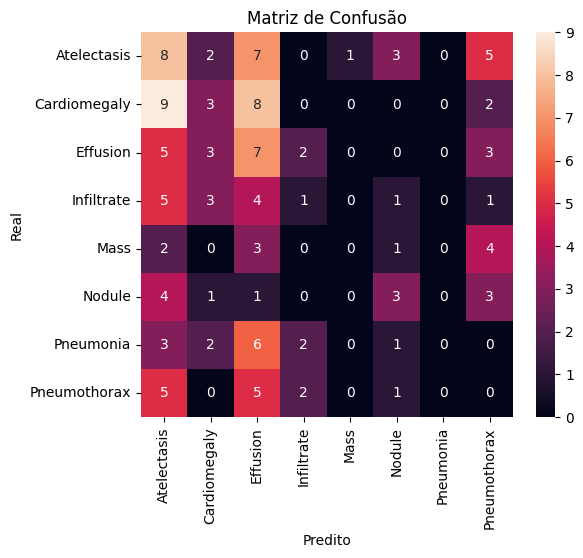


Relatório de Classificação:

              precision    recall  f1-score   support

 Atelectasis       0.20      0.31      0.24        26
Cardiomegaly       0.21      0.14      0.17        22
    Effusion       0.17      0.35      0.23        20
  Infiltrate       0.14      0.07      0.09        15
        Mass       0.00      0.00      0.00        10
      Nodule       0.30      0.25      0.27        12
   Pneumonia       0.00      0.00      0.00        14
Pneumothorax       0.00      0.00      0.00        13

    accuracy                           0.17       132
   macro avg       0.13      0.14      0.12       132
weighted avg       0.14      0.17      0.14       132



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Testes do modelo CNN do zero
# ---------------------------------------------------------------------------
shape_cnn = (224,224,3)
class_cnn = len(train_generator.class_indices)
epoch_cnn = 30

model_cnn = CriarCNN_Simples(shape_cnn,class_cnn)
history_cnn = TreinarModelo(model_cnn, train_generator, val_generator,epoch_cnn)
AvaliarModelo(model_cnn, test_generator)

### **↪ Transfer learning**

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 398s 20s/step - accuracy: 0.1196 - loss: 2.2479 - val_accuracy: 0.1591 - val_loss: 2.0440
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 405s 20s/step - accuracy: 0.2076 - loss: 2.0686 - val_accuracy: 0.2197 - val_loss: 2.0375
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 396s 20s/step - accuracy: 0.2013 - loss: 2.0588 - val_accuracy: 0.1742 - val_loss: 2.0297
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 407s 20s/step - accuracy: 0.1944 - loss: 2.0569 - val_accuracy: 0.1894 - val_loss: 2.0221
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 392s 20s/step - accuracy: 0.2173 - loss: 2.0146 - val_accuracy: 0.1742 - val_loss: 2.0149
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 394s 20s/step - accuracy: 0.2311 - loss: 1.9922 - val_accuracy: 0.1894 - val_loss: 2.0097
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 393s 20s/step - accuracy: 0.2018 - loss: 2.0120 - val_accuracy: 0.1818 - val_loss: 2.0125
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 394s 20s/step - accuracy: 0.2123 - loss: 2.0165 - val_accuracy: 0.

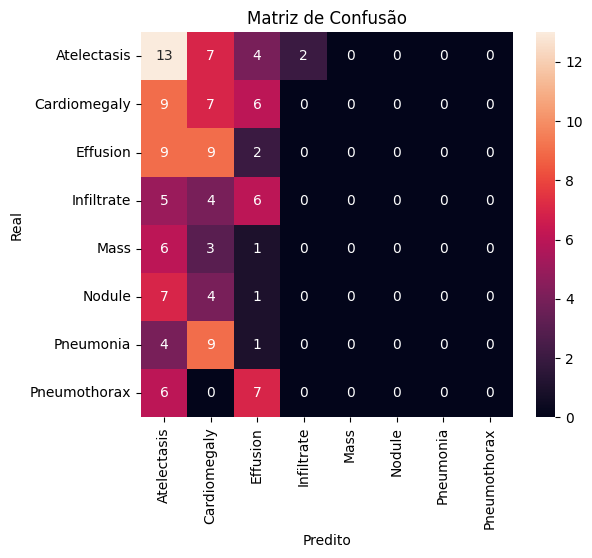


Relatório de Classificação:

              precision    recall  f1-score   support

 Atelectasis       0.22      0.50      0.31        26
Cardiomegaly       0.16      0.32      0.22        22
    Effusion       0.07      0.10      0.08        20
  Infiltrate       0.00      0.00      0.00        15
        Mass       0.00      0.00      0.00        10
      Nodule       0.00      0.00      0.00        12
   Pneumonia       0.00      0.00      0.00        14
Pneumothorax       0.00      0.00      0.00        13

    accuracy                           0.17       132
   macro avg       0.06      0.11      0.08       132
weighted avg       0.08      0.17      0.11       132



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Testes do modelo Transfer Learning
# ---------------------------------------------------------------------------
shape_tl = (224,224,3)
class_tl = len(train_generator.class_indices)
epoch_tl = 30

model_vgg = CriarModelo_TransferLearning(shape_tl, class_tl)
history_vgg = TreinarModelo(model_vgg, train_generator, val_generator, epoch_tl)
AvaliarModelo(model_vgg, test_generator)

### **↪ Resultados**

Saving 00000149_006.png to 00000149_006 (3).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step

Imagem: 00000149_006 (3).png


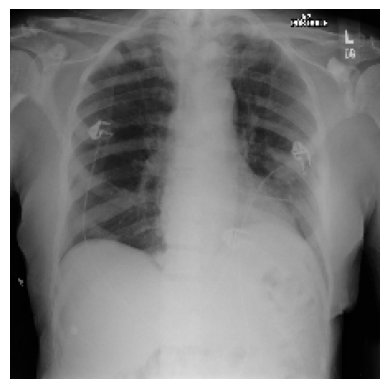

Classe prevista: Atelectasis
Probabilidade: 0.3355


In [ ]:
# Teste do modelo CNN Treinado com imagem aleatória
# ---------------------------------------------------------------------------
target_size = (224, 224)

ClassificarImagem(model_cnn, train_generator.class_indices, target_size)

Saving 00000149_006.png to 00000149_006 (4).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 771ms/step

Imagem: 00000149_006 (4).png


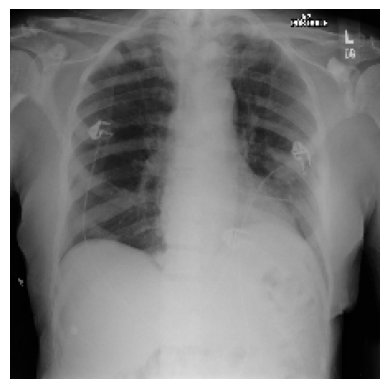

Classe prevista: Atelectasis
Probabilidade: 0.2146


In [ ]:
# Teste do modelo Transfer Learning treinado com imagem aleatória
# ---------------------------------------------------------------------------
target_size = (224, 224)

ClassificarImagem(model_vgg, train_generator.class_indices, target_size)